<a href="https://colab.research.google.com/github/maybraniswe/Retail-Store-Sales-Analysis-and-Prediction/blob/main/PDSE%20Project_Retail%20Store%20Sales%20Analysis%20and%20Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Retail Store Sales Analysis and Prediction**

##**Introduction**
In the modern retail environment, businesses rely on data to understand customer behavior and improve sales performance. Retail transaction data contains valuable information such as product categories, pricing, quantity purchased, and customer purchasing patterns. Analyzing this data helps identify trends, improve decision-making, and support business growth.
This project focuses on a Retail Store Sales dataset, which includes transaction details such as customer ID, product category, item purchased, price per unit, quantity, total spending, payment method, and transaction date.
The project follows a complete data science workflow, including data cleaning, exploratory data analysis (EDA), predictive modeling, and visualization, to generate meaningful insights and support data-driven decisions.

##**Objective**

**Problem Statement**
* To analyze retail sales data and understand factors that influence customer spending and sales performance.

**Data Description**
* To explore and understand the structure of the dataset, including features such as category, item, price, quantity, total spent, and transaction details.

**Data Cleaning & Preprocessing**
* To handle missing values, incorrect data types, and inconsistencies in the dataset to ensure data quality.

**Exploratory Data Analysis (EDA)**
* To analyze patterns and relationships using:
   * Univariate analysis (distribution of variables)
   * Bivariate analysis (relationships between variables)
   * Multivariate analysis (correlation and combined effects)

**Model Development & Tuning**
* To apply at least two machine learning models to predict outcomes such as total spending or customer behavior.
* To improve model performance through parameter tuning.

**Results & Insights**
* To interpret model results and extract meaningful insights from the analysis.

**Visualization & Communication**
* To present findings clearly using charts, graphs, and visualizations.

##Importing Libraries

In [2]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler

Observation:

The required Python libraries were imported successfully for data loading, cleaning, visualization, and preprocessing.

##Data Loading

In [3]:
# read the data from csv file
df = pd.read_csv('https://raw.githubusercontent.com/maybraniswe/Retail-Store-Sales-Analysis-and-Prediction/refs/heads/main/retail_store_sales.csv')
# Dataset size check (rows, columns)
print (df.shape)

(12575, 11)


Observation:

The dataset was loaded successfully. It contains 12,575 rows and 11 columns.

##Preview Data

In [4]:
# View data the first 5 rows
df.head()

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False


Observation:

The first 5 rows were displayed to understand the structure of the dataset and the column names.

It shows sales transaction details such as item, price, quantity, payment method, location, and transaction date.

In [5]:
# View data the first 5 rows
df.tail()

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
12570,TXN_9347481,CUST_18,Patisserie,Item_23_PAT,38.0,4.0,152.0,Credit Card,In-store,2023-09-03,NaN
12571,TXN_4009414,CUST_03,Beverages,Item_2_BEV,6.5,9.0,58.5,Cash,Online,2022-08-12,False
12572,TXN_5306010,CUST_11,Butchers,Item_7_BUT,14.0,10.0,140.0,Cash,Online,2024-08-24,NaN
12573,TXN_5167298,CUST_04,Furniture,Item_7_FUR,14.0,6.0,84.0,Cash,Online,2023-12-30,True
12574,TXN_2407494,CUST_23,Food,Item_9_FOOD,17.0,3.0,51.0,Cash,Online,2022-08-06,NaN


Observation:

The last 5 rows were displayed to verify the dataset loaded properly from beginning to end.

##Check Structure

In [6]:
# Check structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    12575 non-null  object 
 1   Customer ID       12575 non-null  object 
 2   Category          12575 non-null  object 
 3   Item              11362 non-null  object 
 4   Price Per Unit    11966 non-null  float64
 5   Quantity          11971 non-null  float64
 6   Total Spent       11971 non-null  float64
 7   Payment Method    12575 non-null  object 
 8   Location          12575 non-null  object 
 9   Transaction Date  12575 non-null  object 
 10  Discount Applied  8376 non-null   object 
dtypes: float64(3), object(8)
memory usage: 1.1+ MB


Observation:

The dataset contains 11 columns with a mix of categorical and numerical data types. Some columns such as Item, Price Per Unit, Quantity, Total Spent, and Discount Applied have missing values. The Transaction Date column is still in object format and needs conversion to datetime.

##Summary Statistics

In [7]:
# Check summary statistics
df.describe().round(2)

,Price Per Unit,Quantity,Total Spent
count,11966.00,11971.00,11971.00
mean,23.37,5.54,129.65
std,10.74,2.86,94.75
min,5.00,1.00,5.00
25%,14.00,3.00,51.00
50%,23.00,6.00,108.50
75%,33.50,8.00,192.00
max,41.00,10.00,410.00


Observation:

The summary statistics show that the average price per unit is 23.37, the average quantity purchased is 5.54, and the average total spent is 129.65. There is variation in the numerical columns, which suggests different transaction sizes and prices.

##Check Missing Values

In [8]:
# Checking for missing values
df.isnull().sum()

,0
Transaction ID,0
Customer ID,0
Category,0
Item,1213
Price Per Unit,609
Quantity,604
Total Spent,604
Payment Method,0
Location,0
Transaction Date,0


Observation:

Missing values were found in several columns. The Item column has 1,213 missing values, Price Per Unit has 609, Quantity has 604, Total Spent has 604, and Discount Applied has 4,199 missing values. This shows that data cleaning is necessary before analysis.

##Check duplicates

In [9]:
# Remove duplicate rows
print("Duplicate rows before:", df.duplicated().sum())

Duplicate rows before: 0


Observation:

No duplicate rows were found in the dataset, so no rows needed to be removed.

##Check Unique Values

In [10]:
# Check unique values
df['Item'].unique()
df['Item'].value_counts()

,count
Item,
Item_2_BEV,126
Item_25_FUR,113
Item_11_FUR,110
Item_16_MILK,109
Item_1_MILK,109
...,...
Item_5_BEV,7
Item_13_BEV,7
Item_13_FUR,7


In [11]:
# Check unique values
df.nunique()

,0
Transaction ID,12575
Customer ID,25
Category,8
Item,200
Price Per Unit,25
Quantity,10
Total Spent,227
Payment Method,3
Location,2
Transaction Date,1114


##Standardizing Inconsistent Data

In [12]:
# Clean text data (remove spaces, lowercase)
df['Item'] = df['Item'].str.strip().str.lower()
df.head()

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,item_10_pat,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,item_17_milk,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,item_12_but,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,item_16_bev,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,item_6_food,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False


Observation:

The Item column was standardized by removing extra spaces and converting all text to lowercase. This helps make the data consistent and avoids treating similar values as different.

##Converting Data Types

In [13]:
# Convert numeric columns
num_cols = ['Price Per Unit', 'Quantity', 'Total Spent', 'Discount Applied']
for col in num_cols:
    df[col] = pd.to_numeric(df[col])

# Convert date column
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'])

# Convert categorical columns
cat_cols = ['Transaction ID', 'Customer ID', 'Category', 'Item', 'Payment Method', 'Location']
for col in cat_cols:
    df[col] = df[col].astype('category')

print(df.dtypes)

Transaction ID            category
Customer ID               category
Category                  category
Item                      category
Price Per Unit             float64
Quantity                   float64
Total Spent                float64
Payment Method            category
Location                  category
Transaction Date    datetime64[ns]
Discount Applied           float64
dtype: object


Observation:

The data types were converted into appropriate formats. Numerical columns were converted to numeric type, the Transaction Date column was converted to datetime, and categorical columns were converted to category type for better analysis.

## Handling Missing Values

###Create Reference Table

In [14]:
# Create reference table (drop missing first)
item_price_table = df[['Item', 'Price Per Unit']].dropna().drop_duplicates()

# Optional: check
item_price_table.head()

,Item,Price Per Unit
0,item_10_pat,18.5
1,item_17_milk,29.0
2,item_12_but,21.5
3,item_16_bev,27.5
4,item_6_food,12.5


Observation:

A reference table was created using unique combinations of Item and Price Per Unit. This helps to fill missing values based on known relationships.

### Fill Item using Price per Unit

In [15]:
# Create mapping: Price → Item
price_to_item = item_price_table.drop_duplicates('Price Per Unit').set_index('Price Per Unit')['Item']

# Fill missing Item
df['Item'] = df['Item'].fillna(df['Price Per Unit'].map(price_to_item))

Observation:

Missing Item values were filled using the corresponding Price Per Unit from the reference table.

### Fill Price Per Unit using Item

In [16]:
# Create mapping: Item → Price
item_to_price = item_price_table.drop_duplicates('Item').set_index('Item')['Price Per Unit']

# Fill missing Price
df['Price Per Unit'] = df['Price Per Unit'].fillna(df['Item'].map(item_to_price))

Observation:

Missing Price Per Unit values were filled using the corresponding Item from the reference table.

### Fill Quantity

In [17]:
df['Quantity'] = df['Quantity'].fillna(df['Quantity'].median())

Observation:

Missing Quantity values were filled using the median to reduce the effect of outliers.

### Recalculate Total Spent

In [18]:
df['Total Spent'] = df['Price Per Unit'] * df['Quantity']

Observation:

The Total Spent column was recalculated to ensure consistency after filling missing values.

### Discount Applied

In [19]:
# Convert to boolean-like
df['Discount Applied'] = df['Discount Applied'].fillna(False)
df['Discount Applied'] = df['Discount Applied'].astype(bool)

Observation:

Missing values in Discount Applied were filled as False, assuming no discount was applied. The column was converted to boolean format for better clarity and analysis.

In [20]:
# Final check
print(df.isnull().sum())

Transaction ID        0
Customer ID           0
Category              0
Item                609
Price Per Unit      609
Quantity              0
Total Spent         609
Payment Method        0
Location              0
Transaction Date      0
Discount Applied      0
dtype: int64


In [21]:
# Step 1: Create reference table
item_price_table = df[['Item', 'Price Per Unit']].dropna().drop_duplicates()

# Step 2: Fill Item using Price
price_to_item = item_price_table.drop_duplicates('Price Per Unit').set_index('Price Per Unit')['Item']
df['Item'] = df['Item'].fillna(df['Price Per Unit'].map(price_to_item))

# Step 3: Fill Price using Item
item_to_price = item_price_table.drop_duplicates('Item').set_index('Item')['Price Per Unit']
df['Price Per Unit'] = df['Price Per Unit'].fillna(df['Item'].map(item_to_price))

# Step 4: Fill Quantity
df['Quantity'] = df['Quantity'].fillna(df['Quantity'].median())

# Step 5: Recalculate Total
df['Total Spent'] = df['Price Per Unit'] * df['Quantity']

# Step 6: Handle Discount Applied
df['Discount Applied'] = df['Discount Applied'].fillna(False)
df['Discount Applied'] = df['Discount Applied'].astype(bool)

# Final check
print(df.isnull().sum())

Transaction ID        0
Customer ID           0
Category              0
Item                609
Price Per Unit      609
Quantity              0
Total Spent         609
Payment Method        0
Location              0
Transaction Date      0
Discount Applied      0
dtype: int64


Observation:

Instead of using simple imputation, a reference table was created using Item and Price Per Unit to preserve the relationship between variables. Missing values in Item and Price Per Unit were filled using this mapping. Quantity was filled using the median to handle skewness. Total Spent was recalculated to maintain consistency. Discount Applied was treated as a boolean variable, where missing values were assumed as False.

##Univariate Analysis

###1. Histogram – Total Spent

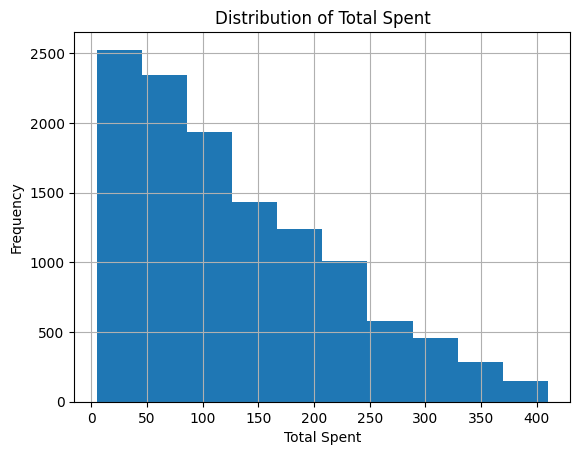

In [22]:
df['Total Spent'].hist()
plt.title("Distribution of Total Spent")
plt.xlabel("Total Spent")
plt.ylabel("Frequency")
plt.show()

Observation:

Most transactions have lower spending, with a few high-value purchases.

###2. Boxplot – Total Spent (Outliers)

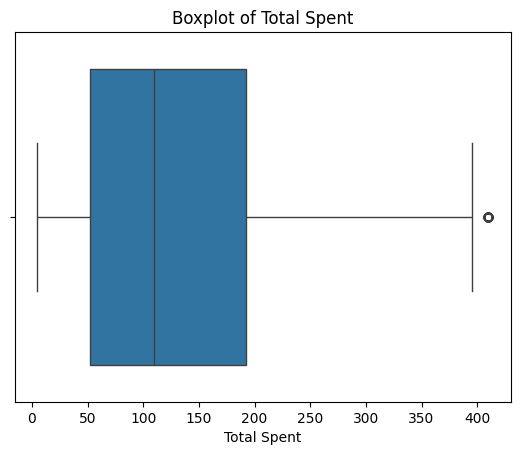

In [50]:
sns.boxplot(x=df['Total Spent'])
plt.title("Boxplot of Total Spent")
plt.show()

Observation:

There are some extreme high spending values (outliers).

###3. Histogram – Quantity




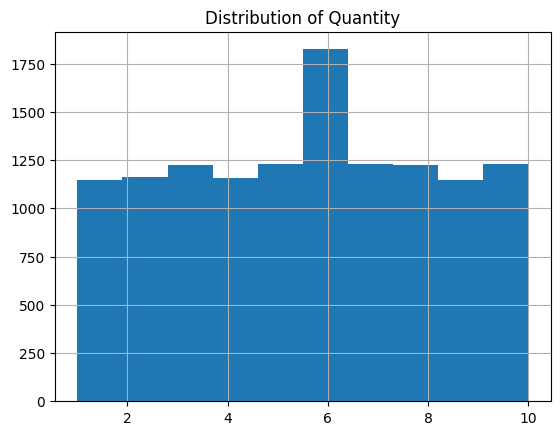

In [49]:
df['Quantity'].hist()
plt.title("Distribution of Quantity")
plt.show()

Observation:

Most customers buy small quantities.

###4. Bar Chart – Category

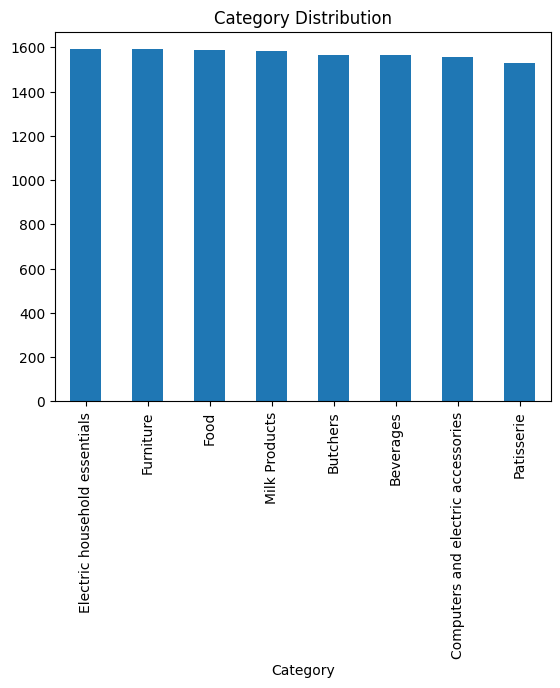

In [51]:
# Category (Bar chart)
df['Category'].value_counts().plot(kind='bar')
plt.title("Category Distribution")
plt.show()

Observation:

Some product categories are more popular than others.

###5. Pie Chart – Payment Method

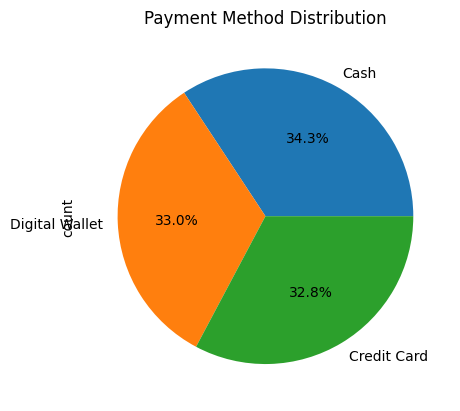

In [52]:
df['Payment Method'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Payment Method Distribution")
plt.show()

Observation:

Digital Wallet or Credit Card is the most commonly used payment method.

##Bivariate/Multivariate Analysis

###6. Scatter Plot – Quantity vs Total Spent

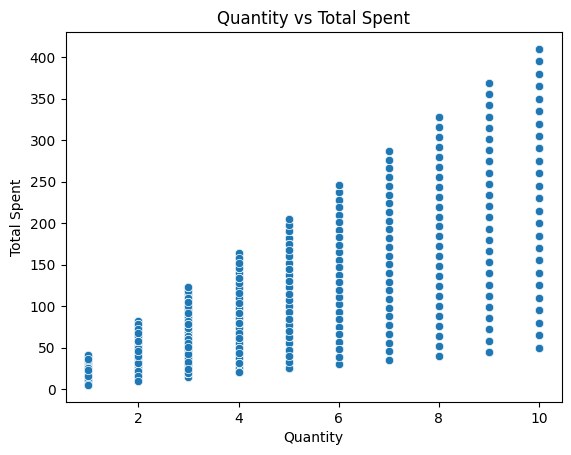

In [53]:
sns.scatterplot(x='Quantity', y='Total Spent', data=df)
plt.title("Quantity vs Total Spent")
plt.show()

Observation:

Higher quantity leads to higher total spending.

###7. Scatter Plot – Price vs Total Spent

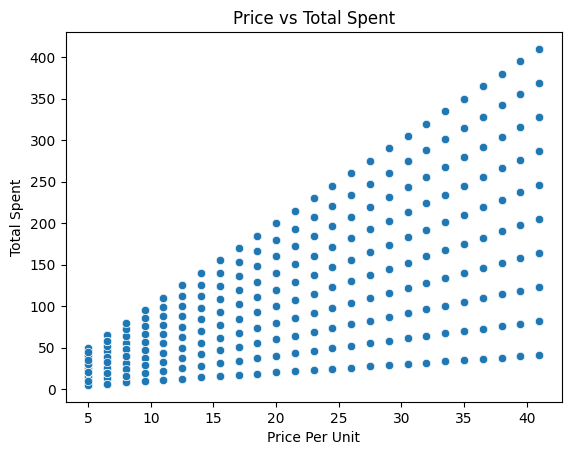

In [54]:
sns.scatterplot(x='Price Per Unit', y='Total Spent', data=df)
plt.title("Price vs Total Spent")
plt.show()

Observation:

Higher price generally increases total spending.

###8. Boxplot – Category vs Total Spent

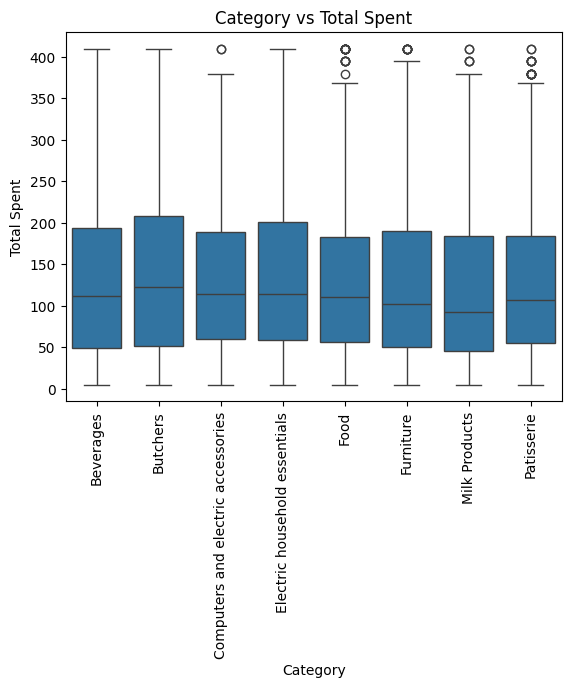

In [56]:
sns.boxplot(x='Category', y='Total Spent', data=df)
plt.xticks(rotation=90)
plt.title("Category vs Total Spent")
plt.show()

Observation:

Some categories have higher spending than others.

###9. Boxplot – Total Spent vs Payment Method

<Axes: xlabel='Payment Method', ylabel='Total Spent'>

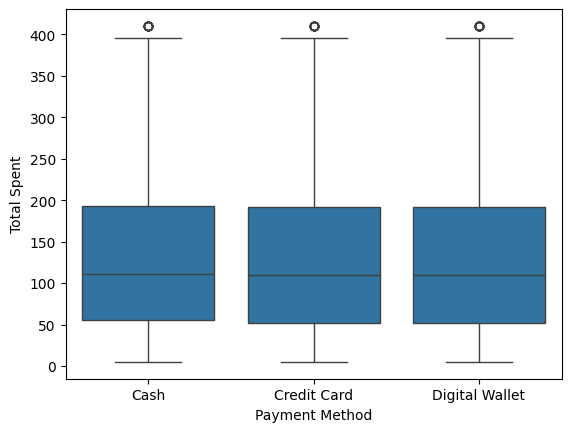

In [57]:
sns.boxplot(x='Payment Method', y='Total Spent', data=df)

###10. Boxplot – Total Spent vs Location

<Axes: xlabel='Location', ylabel='Total Spent'>

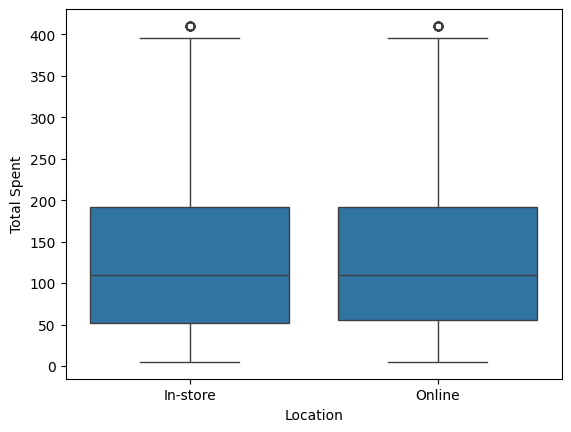

In [58]:
sns.boxplot(x='Location', y='Total Spent', data=df)

###11. Heatmap – Correlation

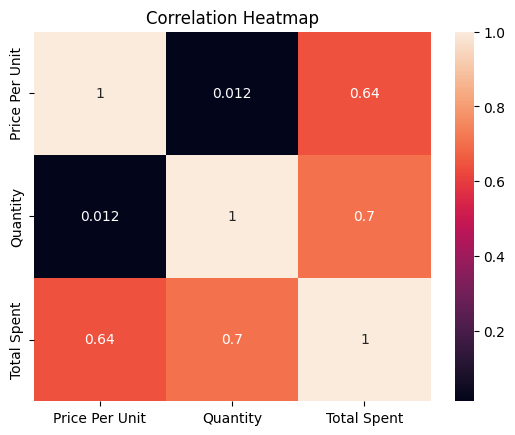

In [59]:
sns.heatmap(df[['Price Per Unit','Quantity','Total Spent']].corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

Observation:

Total Spent is strongly related to Quantity and Price.

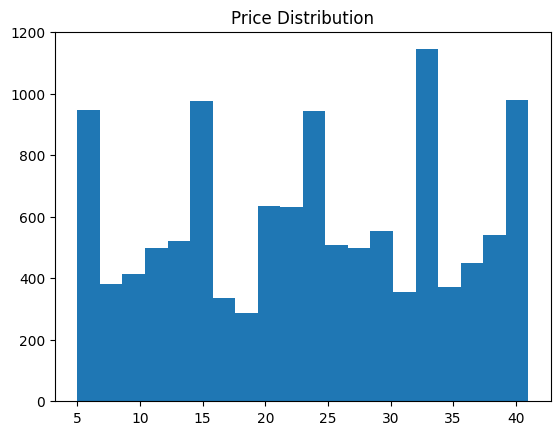

In [25]:
# Price Per Unit (Histogram)
plt.hist(df['Price Per Unit'], bins=20)
plt.title("Price Distribution")
plt.show()

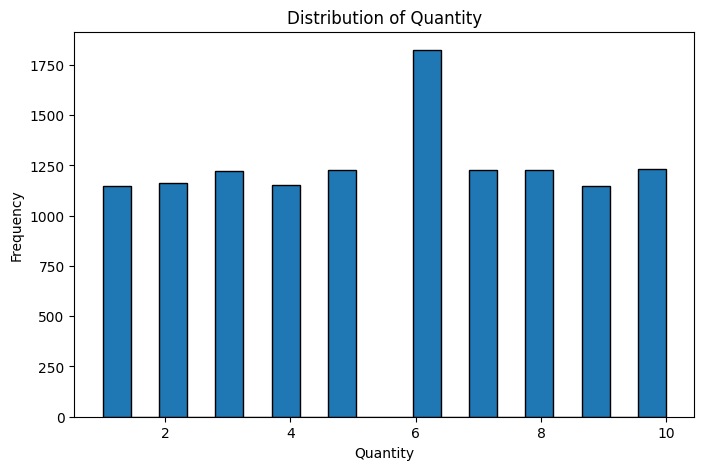

In [26]:
plt.figure(figsize=(8,5))
plt.hist(df['Quantity'], bins=20, edgecolor='black')
plt.title('Distribution of Quantity')
plt.xlabel('Quantity')
plt.ylabel('Frequency')
plt.show()

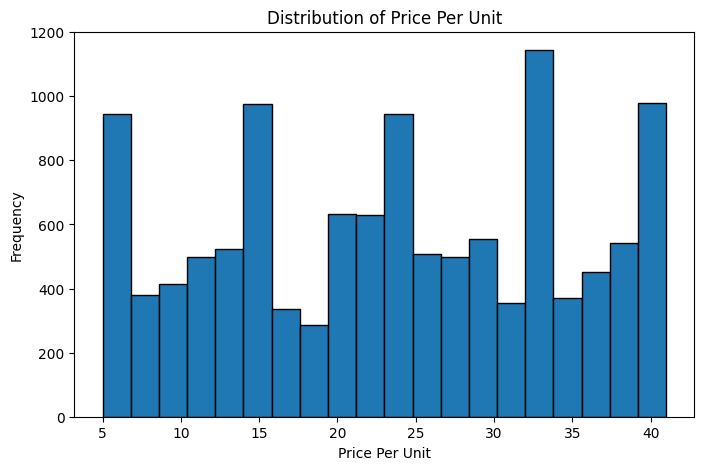

In [28]:
plt.figure(figsize=(8,5))
plt.hist(df['Price Per Unit'], bins=20, edgecolor='black')
plt.title('Distribution of Price Per Unit')
plt.xlabel('Price Per Unit')
plt.ylabel('Frequency')
plt.show()

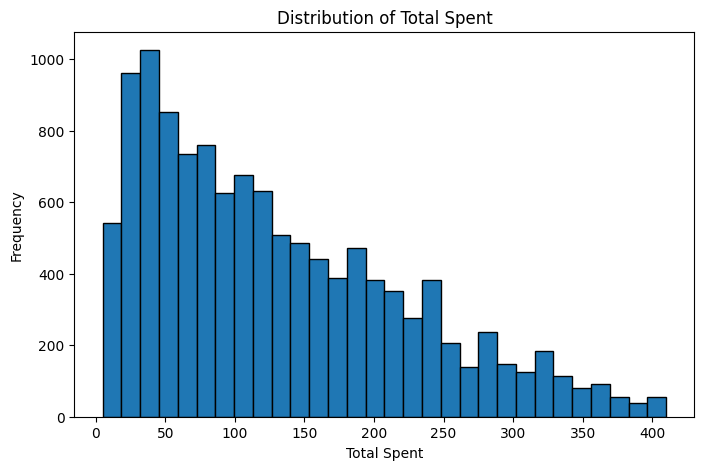

In [31]:
plt.figure(figsize=(8,5))
plt.hist(df['Total Spent'], bins=30, edgecolor='black')
plt.title('Distribution of Total Spent')
plt.xlabel('Total Spent')
plt.ylabel('Frequency')
plt.show()

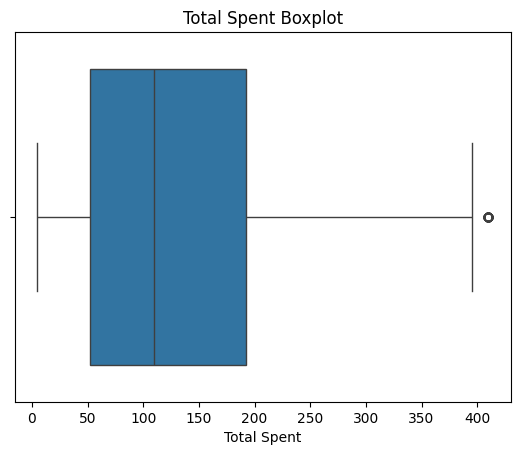

In [33]:
# Total Spent (Boxplot)
sns.boxplot(x=df['Total Spent'])
plt.title("Total Spent Boxplot")
plt.show()

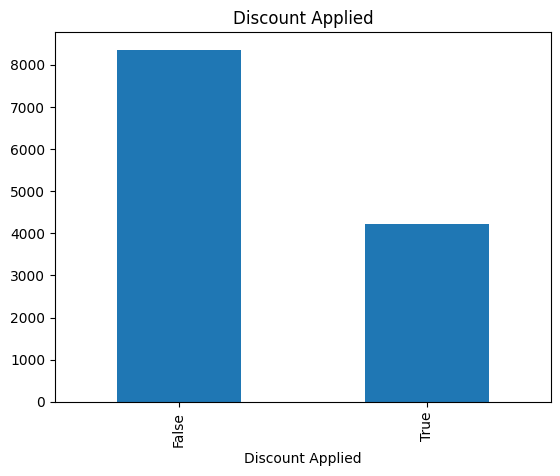

In [36]:
# Discount Applied (Bar chart)
df['Discount Applied'].value_counts().plot(kind='bar')
plt.title("Discount Applied")
plt.show()

##Multivariate Analysis

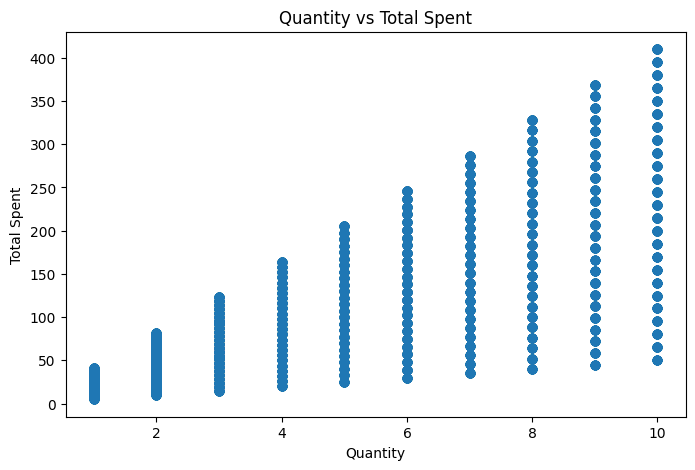

In [38]:
plt.figure(figsize=(8,5))
plt.scatter(df['Quantity'], df['Total Spent'], alpha=0.5)
plt.title('Quantity vs Total Spent')
plt.xlabel('Quantity')
plt.ylabel('Total Spent')
plt.show()

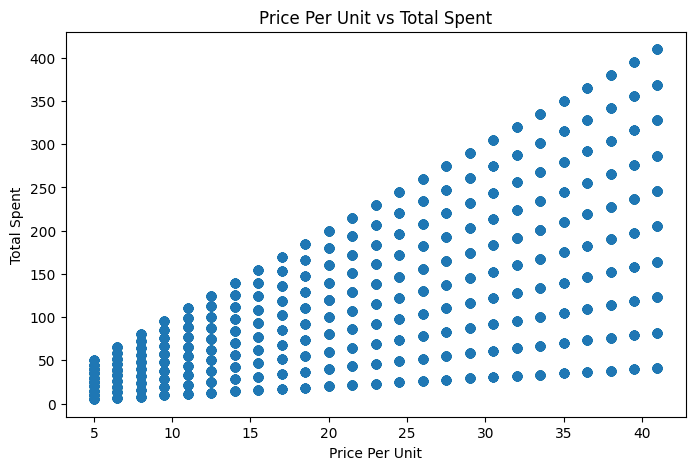

In [39]:
plt.figure(figsize=(8,5))
plt.scatter(df['Price Per Unit'], df['Total Spent'], alpha=0.5)
plt.title('Price Per Unit vs Total Spent')
plt.xlabel('Price Per Unit')
plt.ylabel('Total Spent')
plt.show()

/tmp/ipykernel_19241/3309953998.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top_qty = df.groupby('Item')['Quantity'].sum().sort_values(ascending=False).head(10)


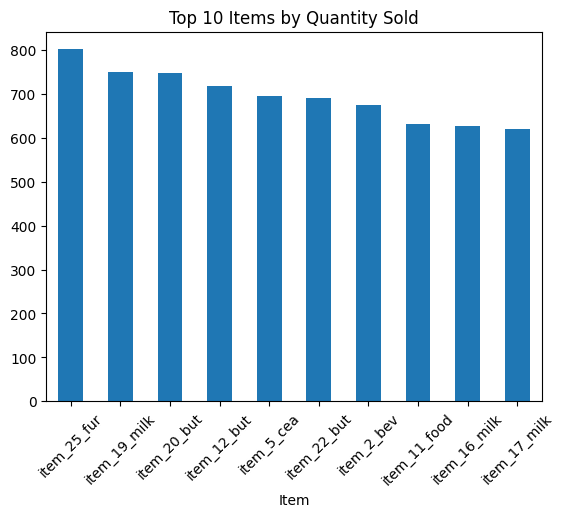

In [43]:
top_qty = df.groupby('Item')['Quantity'].sum().sort_values(ascending=False).head(10)

top_qty.plot(kind='bar')
plt.title("Top 10 Items by Quantity Sold")
plt.xticks(rotation=45)
plt.show()

/tmp/ipykernel_19241/1608570124.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top_items = df.groupby('Item')['Total Spent'].sum().sort_values(ascending=False).head(10)


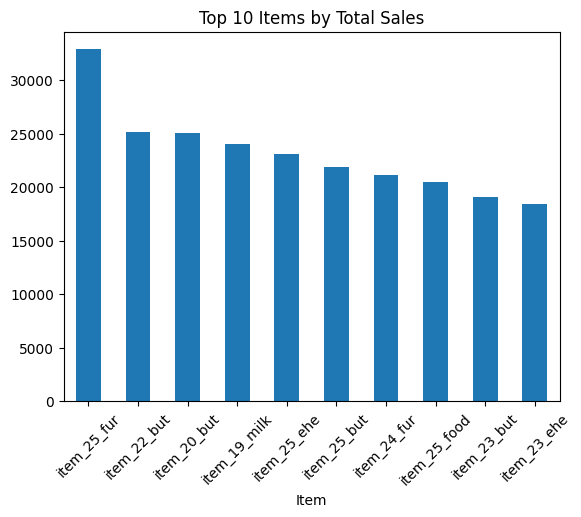

In [44]:
top_items = df.groupby('Item')['Total Spent'].sum().sort_values(ascending=False).head(10)

top_items.plot(kind='bar')
plt.title("Top 10 Items by Total Sales")
plt.xticks(rotation=45)
plt.show()

##Heatmap

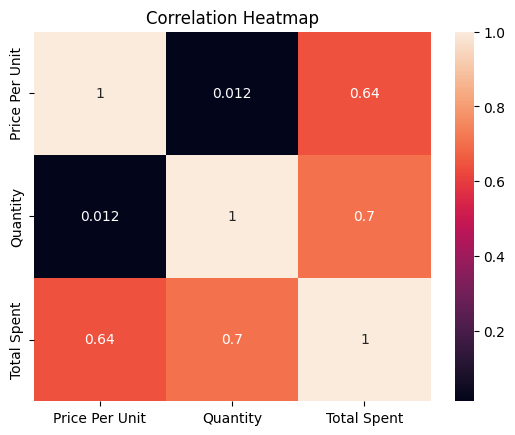

In [46]:
corr = df[['Price Per Unit', 'Quantity', 'Total Spent']].corr()

sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()